Ensemble

Definition:
Ensemble learning combines multiple models to improve prediction accuracy, stability, and generalization.

Objective:
Reduce variance, bias, and improve robustness by aggregating predictions from multiple base models.

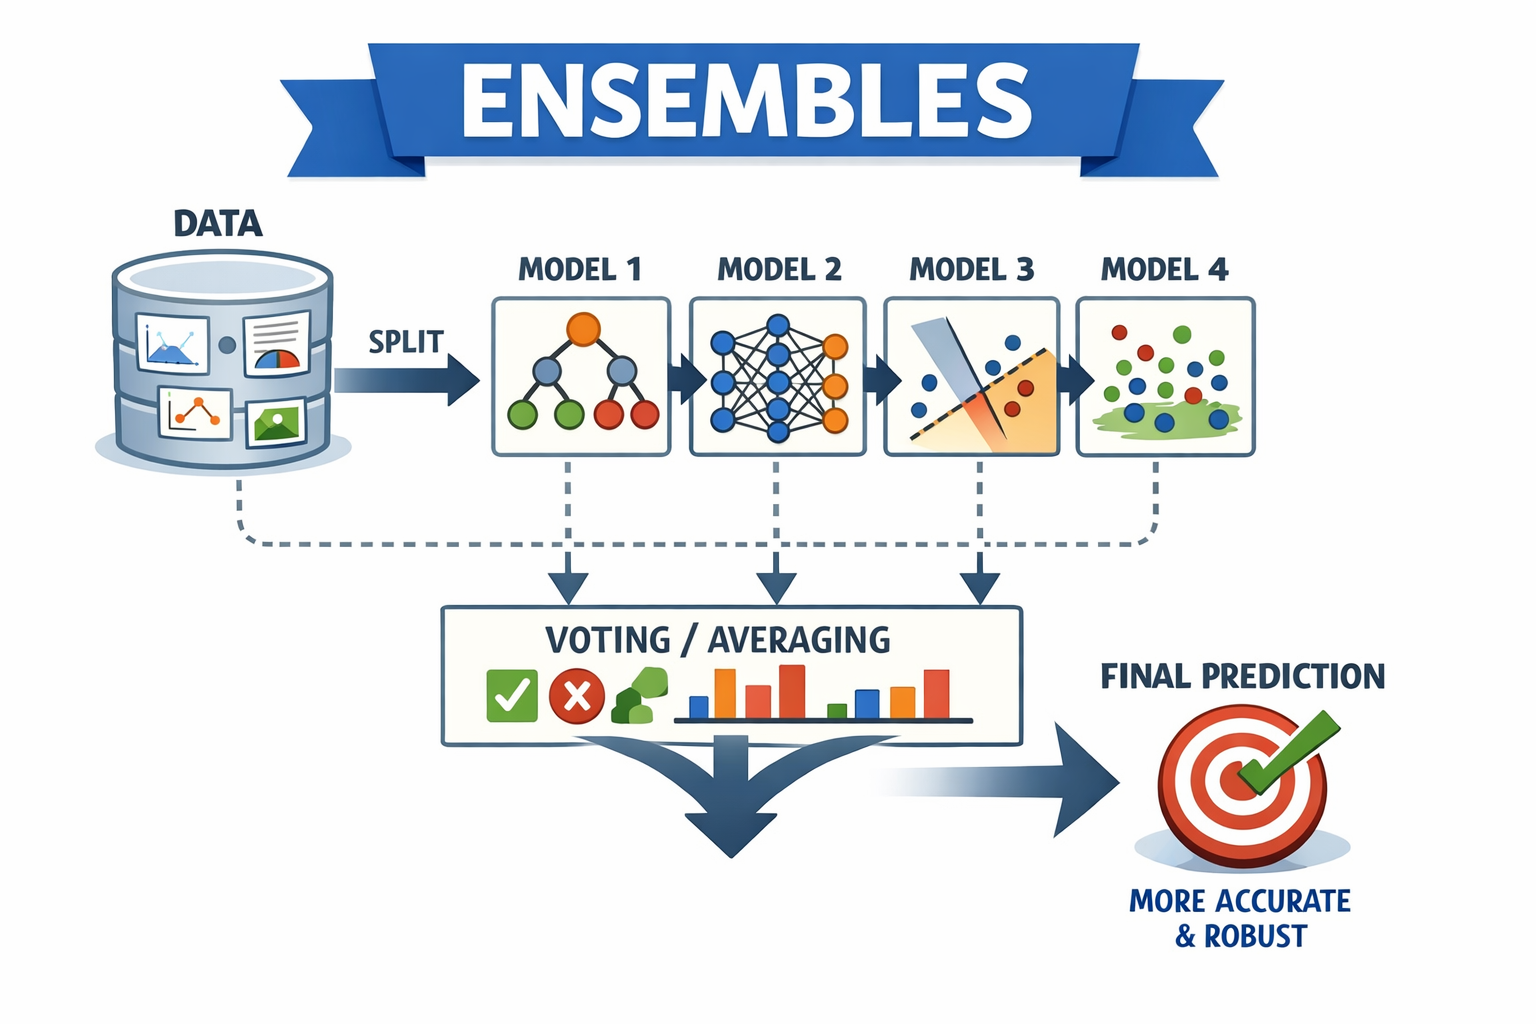

Types of Ensemble Methods
1) Averaging Methods:
Train models independently,
Combine predictions (mean/majority vote),
Helps reduce variance

2) Boosting Methods:
Train models sequentially,
Each model corrects previous errors,
Converts weak learners into a strong model

Models Used in This Project
Logistic Regression → strong linear baseline

Decision Tree Classifier → captures non-linear patterns (may overfit)

Random Forest Classifier → robust and high performance

VotingClassifier → combines all models into one ensemble


Dataset

Breast Cancer Wisconsin dataset from scikit-learn

Features: 30 numerical attributes (e.g., radius, texture, area)

Target:
0 → Malignant
1 → Benign



Task

Perform data analysis

Train individual models

Combine models using VotingClassifier

Evaluate using accuracy, confusion matrix, and classification report

Conclusion

Logistic Regression → stable baseline

Decision Tree → flexible but may overfit

Random Forest → strong overall performance

VotingClassifier → improves robustness and often matches or exceeds best model

Imports (Key Tools)

NumPy, pandas → data handling

matplotlib, seaborn → visualization

train_test_split → data splitting

accuracy_score, confusion matrix → evaluation

Logistic Regression, Decision Tree, Random Forest → models

VotingClassifier → ensemble model

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier

In [ ]:
cancer = load_breast_cancer(as_frame=True)
data = cancer.frame

data.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

Target Distribution and Exploration

The distribution of the target variable is analyzed using value_counts() to quantify the number of observations in each class (malignant vs. benign), enabling detection of potential class imbalance prior to model training. Additionally, exploratory analysis of the mean radius feature is performed באמצעות a histogram with kernel density estimation (KDE), providing insight into its distributional characteristics, including skewness, variability, and potential outliers. This analysis aids in understanding feature behavior and its potential impact on model performance.

In [ ]:
data['target'].value_counts()

,count
target,
1,357
0,212


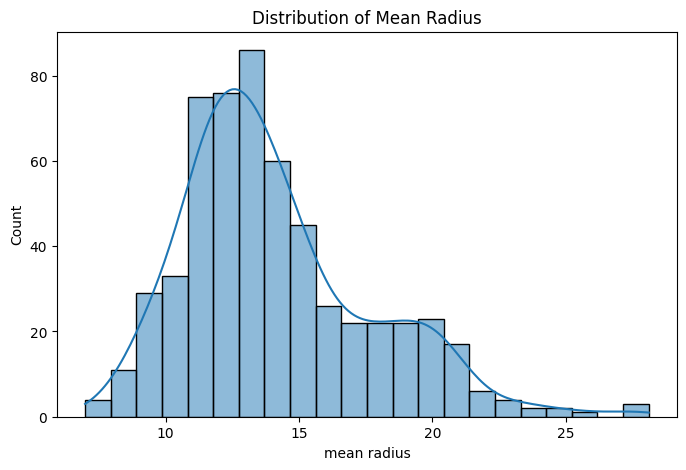

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data['mean radius'], kde=True)
plt.title("Distribution of Mean Radius")
plt.show()

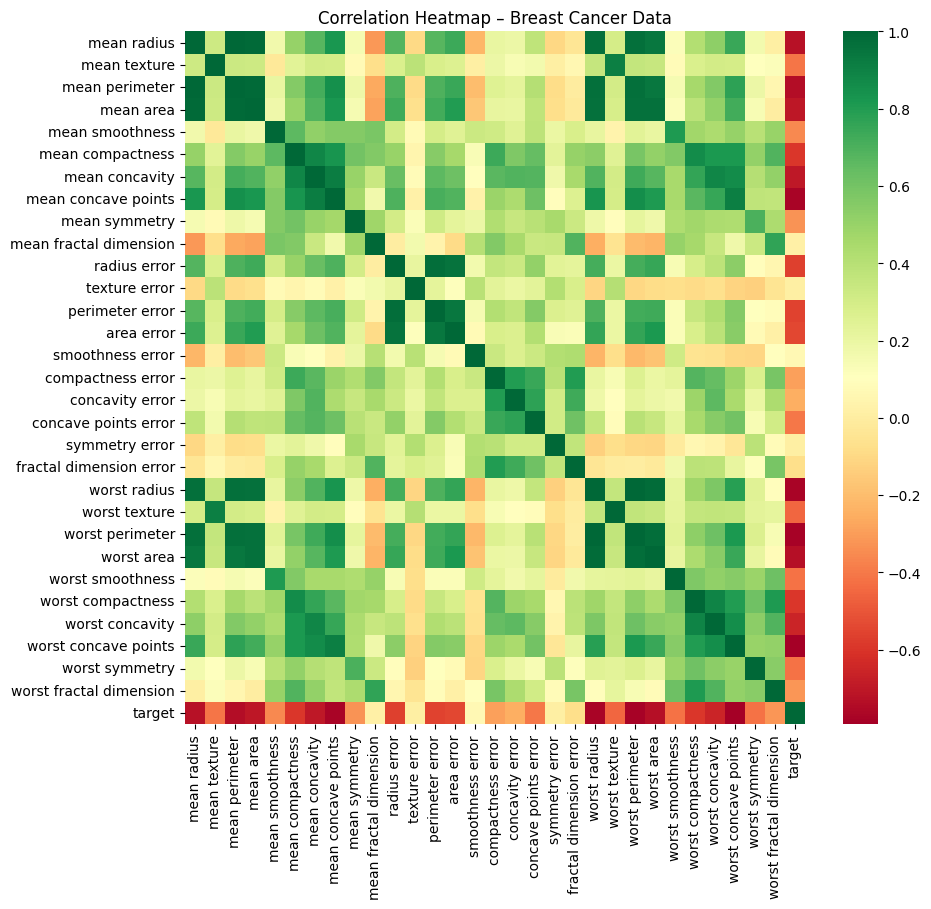

In [ ]:
plt.figure(figsize=(10, 9))
sns.heatmap(data.corr(), cmap='RdYlGn')
plt.title("Correlation Heatmap – Breast Cancer Data")
plt.show()


Feature and Train-Test Split

The dataset is partitioned into input features (X) and the target variable (y), where X contains all predictor variables and y represents the binary outcome indicating whether a tumor is malignant or benign. Verifying the dimensions of X and y ensures that the data has been correctly structured for subsequent modeling tasks. The data is then split into training and testing subsets using a 70/30 ratio. The use of stratification preserves the original class distribution across both sets, which is critical for unbiased model evaluation, while a fixed random state ensures reproducibility. This preparation step establishes a robust framework for training and validating classification models on unseen data.

In [ ]:
X = data.drop(columns=['target'])
y = data['target']

print(X.shape, y.shape)

(569, 30) (569,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


Train and Evaluate Base Model

Three classification models are initialized and trained on the breast cancer training dataset to capture different learning behaviors. Logistic Regression is configured with an increased number of iterations to ensure proper convergence given the feature space. The Random Forest Classifier leverages an ensemble of decision trees to model complex, non-linear relationships, while the Decision Tree Classifier provides a more interpretable structure through hierarchical feature-based splits. Each model is trained using the training data (X_train, y_train), preparing them for performance evaluation.

Model performance is then assessed using a custom evaluation function that computes accuracy on both training and testing datasets. This enables a direct comparison of Logistic Regression, Random Forest, and Decision Tree classifiers, while also helping identify signs of overfitting or underfitting. The results provide a clear understanding of each model’s classification capability on malignant and benign tumor prediction prior to applying ensemble techniques.

In [ ]:
logistic = LogisticRegression(max_iter=5000)
rf = RandomForestClassifier(random_state=42)
dt = DecisionTreeClassifier(random_state=42)

logistic.fit(X_train, y_train)
rf.fit(X_train, y_train)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
def eval_classifier(name, model, X_train, y_train, X_test, y_test):
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)

    print(f"{name}")
    print(f" Train - Accuracy : {acc_train:.3f}")
    print(f" Test  - Accuracy : {acc_test:.3f}")
    print("-" * 40)

eval_classifier("LogisticRegression", logistic, X_train, y_train, X_test, y_test)
eval_classifier("RandomForestClassifier", rf, X_train, y_train, X_test, y_test)
eval_classifier("DecisionTreeClassifier", dt, X_train, y_train, X_test, y_test)


LogisticRegression
 Train - Accuracy : 0.970
 Test  - Accuracy : 0.947
----------------------------------------
RandomForestClassifier
 Train - Accuracy : 1.000
 Test  - Accuracy : 0.936
----------------------------------------
DecisionTreeClassifier
 Train - Accuracy : 1.000
 Test  - Accuracy : 0.918
----------------------------------------


A ***VotingClassifier*** is implemented by aggregating Logistic Regression, Random Forest, and Decision Tree classifiers into a unified ensemble using hard voting, where the final prediction is determined by majority class agreement among the base models. Each individual classifier, along with the ensemble model, is trained on the training dataset and subsequently evaluated on the test set. Comparative analysis of accuracy scores across all models enables assessment of performance gains, highlighting whether the ensemble approach enhances predictive accuracy relative to the standalone classifiers.

In [ ]:
voting_clf = VotingClassifier(
    estimators=[
        ('lr', logistic),
        ('rf', rf),
        ('dt', dt)
    ],
    voting='hard'
)

for clf in [logistic, rf, dt, voting_clf]:
    clf.fit(X_train, y_train)
    y_pred_clf = clf.predict(X_test)
    print(f"{clf.__class__.__name__}, accuracy score = {accuracy_score(y_test, y_pred_clf):.3f}")


LogisticRegression, accuracy score = 0.947
RandomForestClassifier, accuracy score = 0.936
DecisionTreeClassifier, accuracy score = 0.918
VotingClassifier, accuracy score = 0.953


The performance of the ensemble model is further evaluated using a ***confusion matrix*** and classification report. The confusion matrix, visualized as a heatmap, illustrates the distribution of correct and incorrect predictions across the two classes (malignant and benign), with a strong concentration along the diagonal indicating accurate classification. The classification report complements this by providing key performance metrics precision, recall, F1-score, and support for each class, offering a detailed assessment of the model’s ability to distinguish between malignant and benign cases. Collectively, these evaluation measures demonstrate the ensemble model’s effectiveness in delivering stable predictions and high classification accuracy on the breast cancer dataset. *italicized text*

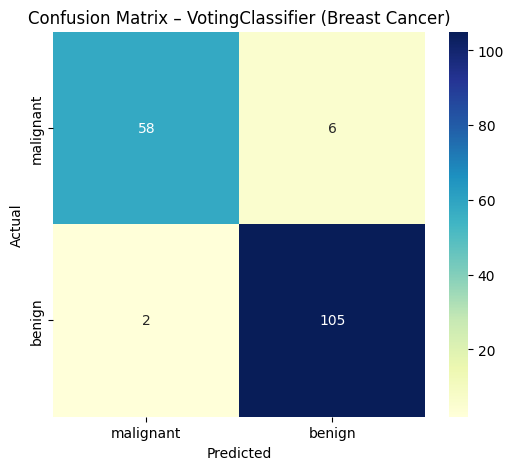

              precision    recall  f1-score   support

   malignant       0.97      0.91      0.94        64
      benign       0.95      0.98      0.96       107

    accuracy                           0.95       171
   macro avg       0.96      0.94      0.95       171
weighted avg       0.95      0.95      0.95       171



In [ ]:
y_pred_voting = voting_clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_voting)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap="YlGnBu",
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names)
plt.title("Confusion Matrix – VotingClassifier (Breast Cancer)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cr = classification_report(y_test, y_pred_voting, target_names=cancer.target_names)
print(cr)


The VotingClassifier demonstrates strong classification performance, achieving an overall accuracy of approximately 95%, which indicates high predictive reliability on the test dataset. For the malignant class, the model attains high precision (~0.97) and solid recall (~0.91), suggesting effective identification of cancerous cases while maintaining a low false positive rate. For the benign class, the classifier achieves very high recall (~0.98) and strong precision (~0.95), highlighting its ability to accurately detect non-cancerous instances. Furthermore, the macro and weighted average scores (around 0.95) indicate balanced performance across both classes. Overall, the ensemble model exhibits robust generalization, minimal misclassification, and strong diagnostic effectiveness on the breast cancer dataset.